# Week 13 optimisation strategy — 12th query submission

## tl;dr

The supplied cumulative Week 12 files reproduce all 88 published Week 1–11 pairs exactly and add eight aligned Week 12 evaluations. The corrected cumulative data are used to refit eight anisotropic Matérn-5/2 Gaussian Processes. One bounded, finite, six-decimal and previously unevaluated Week 13 query is selected for every function after comparing UCB, EI and PI. This is the sole canonical Week 13 methodology; Week 13 outcomes have not been observed.

## Context & Methods

**Primary evidence:** the supplied `week_12_inputs.txt` and `week_12_outputs.txt`, preserved byte-for-byte under `Results/source_evidence/week_12/`. Their SHA-256 hashes and source-file date are recorded in the ledger and validation report.

The pre-reconciliation Week 12 query file repeated the Week 11 queries and matched none of the supplied final-round inputs. It is preserved under `Week_12/01_Queries/archive/`; the supplied 12th input row is now the active Week 12 submission record.

### Key assumptions

- Each function is maximised independently on `[0,1]^d`.
- The exact 88-pair prefix match establishes continuity with the published ledger.
- Source-file dates are provenance metadata, not authoritative platform timestamps.
- GP predictions guide an expensive next evaluation but do not prove global optimality.
- The function-specific acquisition policy was fixed after observing Week 12 and before any Week 13 outcomes. It is adaptive and heuristic, not a randomised or statistically controlled comparison of UCB, EI and PI.

In [1]:
from pathlib import Path
import json,sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib','inline')
ROOT=Path.cwd().resolve()
while not (ROOT/'Code').is_dir() and ROOT!=ROOT.parent: ROOT=ROOT.parent
sys.path.insert(0,str(ROOT))
from Code.weekly_evidence import DIMENSIONS,pairs_through_week
from Code.data_validation import validate_observations
ledger=pd.read_csv(ROOT/'Results/query_output_ledger.csv')
strategy=pd.read_csv(ROOT/'Week_13/04_Results/week_13_strategy_summary.csv')
comparison=pd.read_csv(ROOT/'Week_13/04_Results/week_13_acquisition_comparison.csv')
validation=json.loads((ROOT/'Results/week_12_evidence_validation.json').read_text())
print(f'Repository: {ROOT}')

Repository: /Users/john-peteramewu/Documents/Codex/2026-08-07/understand-the-project-explain-the-structure/work/publish-week11.wwIJ2I


## Data

### Week 12 reconciliation and returned observations

In [2]:
assert validation['historical_prefix_pairs_checked']==88
assert validation['historical_prefix_mismatches']==0
assert validation['week_12_pairs_appended']==8
week12=ledger.loc[ledger.week.eq(12),['function','query','returned_output','evidence_status']]
week12

,function,query,returned_output,evidence_status
88,1,"[0.997915,0.748997]",-1.623962e-106,verified_cumulative_archive_pair_after_query_r...
89,2,"[0.692505,0.619198]",6.073819e-01,verified_cumulative_archive_pair_after_query_r...
90,3,"[0.737864,0.713916,0.373523]",-2.262932e-02,verified_cumulative_archive_pair_after_query_r...
91,4,"[0.370439,0.382409,0.425133,0.390888]",3.699753e-01,verified_cumulative_archive_pair_after_query_r...
92,5,"[0.09922,0.956523,0.978678,0.993262]",3.546632e+03,verified_cumulative_archive_pair_after_query_r...
93,6,"[0.542094,0.205654,0.578843,0.946832,0.036709]",-5.378218e-01,verified_cumulative_archive_pair_after_query_r...
94,7,"[0.108717,0.301229,0.470084,0.22803,0.331784,0...",2.266802e+00,verified_cumulative_archive_pair_after_query_r...
95,8,"[0.123374,0.09797,0.065526,0.059094,0.757317,0...",9.926835e+00,verified_cumulative_archive_pair_after_query_r...


### Data-quality profile

The intended grain is one evaluated query and one scalar response per function. The checks below cover row alignment, dimensions, finite values, unit-hypercube bounds and exact duplicates.

In [3]:
evidence={}; quality=[]
for function in range(1,9):
    data=ROOT/f'Week_01/Function_{function:02d}/03_Data'
    inputs=np.load(data/'initial_inputs.npy'); outputs=np.load(data/'initial_outputs.npy').reshape(-1)
    pairs=pairs_through_week(12,function)
    inputs=np.vstack([inputs]+[np.asarray(query,float)[None,:] for query,_ in pairs])
    outputs=np.r_[outputs,[value for _,value in pairs]]
    inputs,outputs=validate_observations(inputs,outputs,dimensions=DIMENSIONS[function])
    rounded=np.round(inputs,6); duplicate_rows=len(rounded)-len(np.unique(rounded,axis=0))
    evidence[function]=(inputs,outputs)
    quality.append({'Function':f'F{function}','Rows':len(outputs),'Dimensions':inputs.shape[1],'Missing values':int(np.isnan(inputs).sum()+np.isnan(outputs).sum()),'Out-of-bounds coordinates':int(((inputs<0)|(inputs>1)).sum()),'Repeated rows at 6dp':duplicate_rows,'Minimum output':outputs.min(),'Mean output':outputs.mean(),'Output SD':outputs.std(),'Maximum output':outputs.max(),'Latest output':outputs[-1]})
quality=pd.DataFrame(quality); quality

,Function,Rows,Dimensions,Missing values,Out-of-bounds coordinates,Repeated rows at 6dp,Minimum output,Mean output,Output SD,Maximum output,Latest output
0,F1,22,2,0,0,0,-0.003606,-0.000164,0.000751,7.710875e-16,-1.623962e-106
1,F2,22,2,0,0,0,-0.065624,0.165305,0.202569,6.112052e-01,6.073819e-01
2,F3,27,3,0,0,0,-0.398926,-0.092309,0.070650,-2.262932e-02,-2.262932e-02
3,F4,42,4,0,0,0,-32.625660,-16.900558,7.812467,3.699753e-01,3.699753e-01
4,F5,32,4,0,0,1,0.112940,433.509650,709.293018,3.546632e+03,3.546632e+03
5,F6,32,5,0,0,0,-2.571170,-1.457394,0.489986,-5.378218e-01,-5.378218e-01
6,F7,42,6,0,0,0,0.002701,0.487037,0.592093,2.266802e+00,2.266802e+00
7,F8,52,8,0,0,0,5.592193,8.156540,1.061563,9.939904e+00,9.926835e+00


### Standardised output distributions

Raw outputs are not comparable across functions. This box plot standardises each function independently so spread and outliers can be compared without mixing objective units.

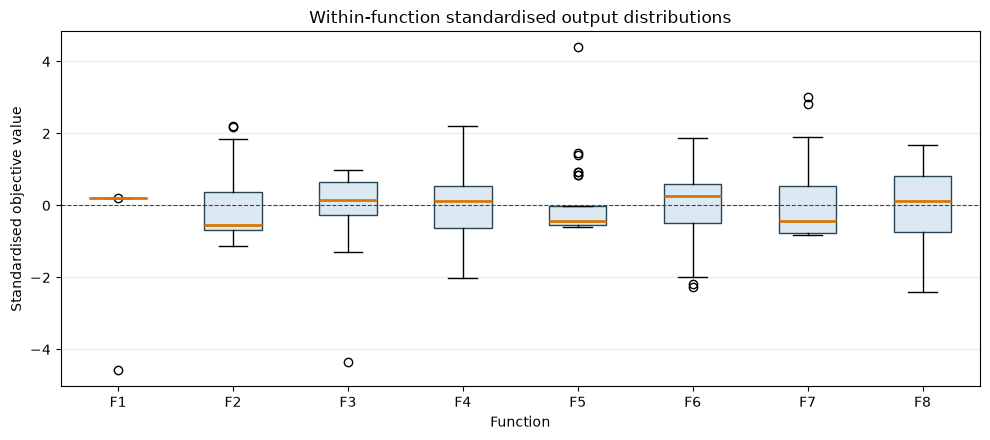

In [4]:
standardised=[]
for function,(inputs,outputs) in evidence.items():
    scale=outputs.std() or 1.0
    standardised.append((outputs-outputs.mean())/scale)
fig,ax=plt.subplots(figsize=(10,4.5))
ax.boxplot(standardised,tick_labels=[f'F{i}' for i in range(1,9)],patch_artist=True,boxprops={'facecolor':'#dce9f2','edgecolor':'#264653'},medianprops={'color':'#d97706','linewidth':2})
ax.axhline(0,color='#444',lw=.8,ls='--'); ax.set(title='Within-function standardised output distributions',xlabel='Function',ylabel='Standardised objective value')
ax.grid(axis='y',alpha=.25); fig.tight_layout(); plt.show()

### Updated within-function performance

In [5]:
performance=strategy[['function','verified_observations','verified_best','week_12_output','week_12_improvement']].copy()
performance['improved_incumbent']=performance.week_12_improvement>0
performance

,function,verified_observations,verified_best,week_12_output,week_12_improvement,improved_incumbent
0,1,22,7.710875e-16,-1.623962e-106,-7.710875e-16,False
1,2,22,6.112052e-01,6.073819e-01,-3.823277e-03,False
2,3,27,-2.262932e-02,-2.262932e-02,1.220599e-02,True
3,4,42,3.699753e-01,3.699753e-01,2.351050e+00,True
4,5,32,3.546632e+03,3.546632e+03,2.081120e+03,True
5,6,32,-5.378218e-01,-5.378218e-01,1.764431e-01,True
6,7,42,2.266802e+00,2.266802e+00,1.168963e-01,True
7,8,52,9.939904e+00,9.926835e+00,-1.306883e-02,False


### Per-function trajectories, running best and input coverage

Each function is plotted in its own objective units. Orange diamonds mark the verified Week 12 evaluation and stars mark the incumbent. The coordinate heatmap shows how the evaluated inputs cover each dimension.

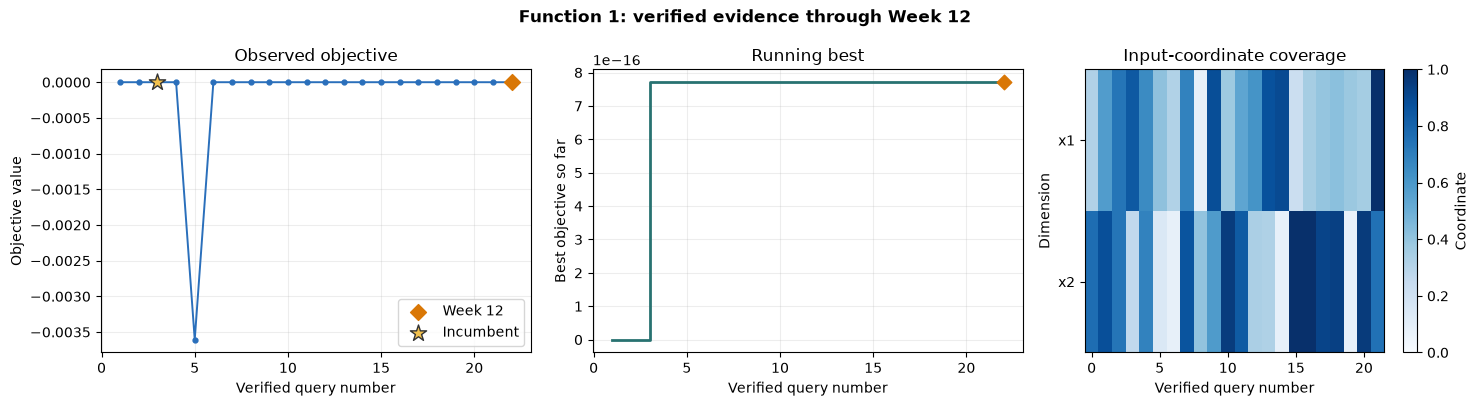

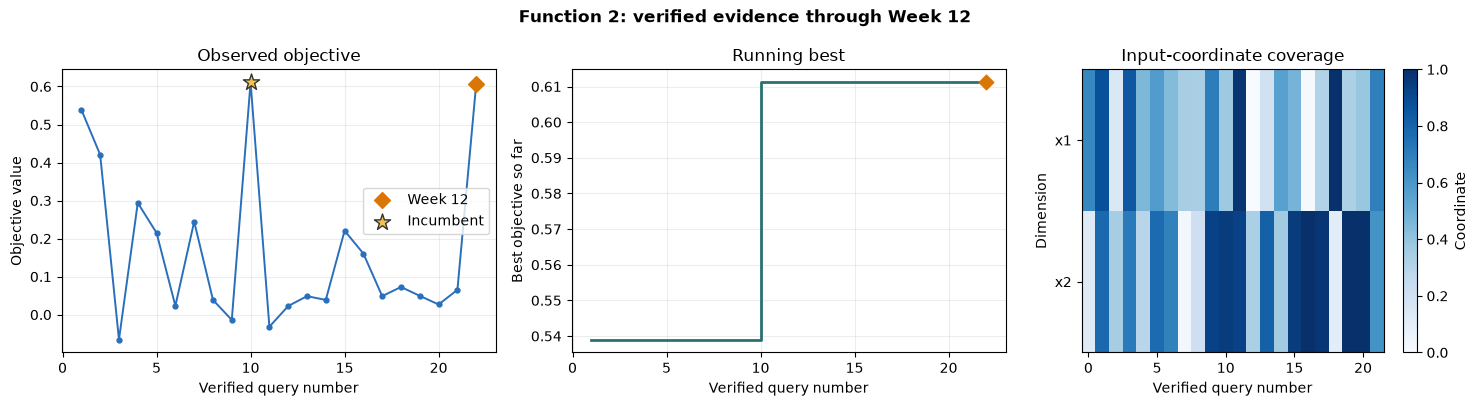

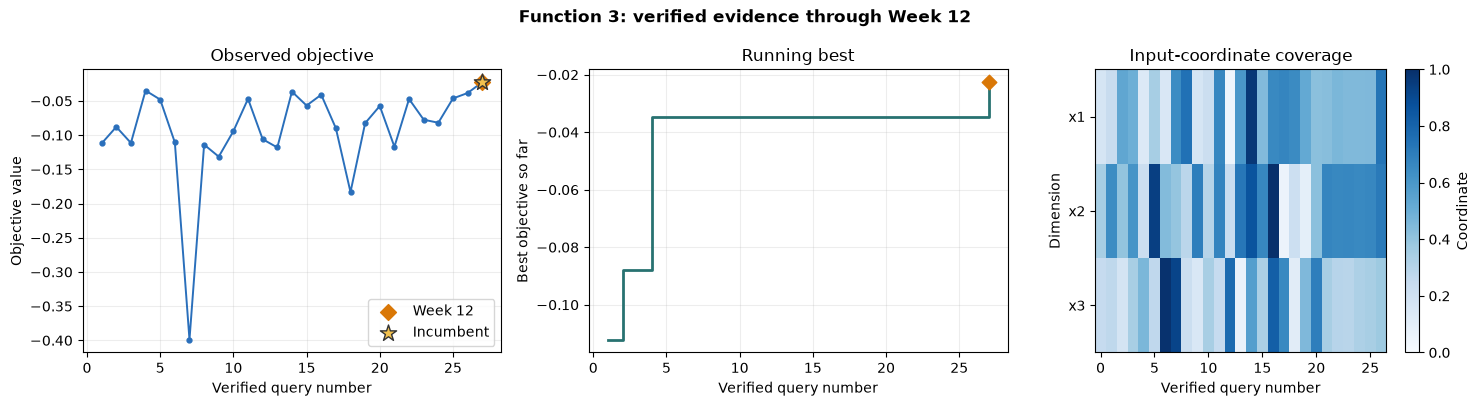

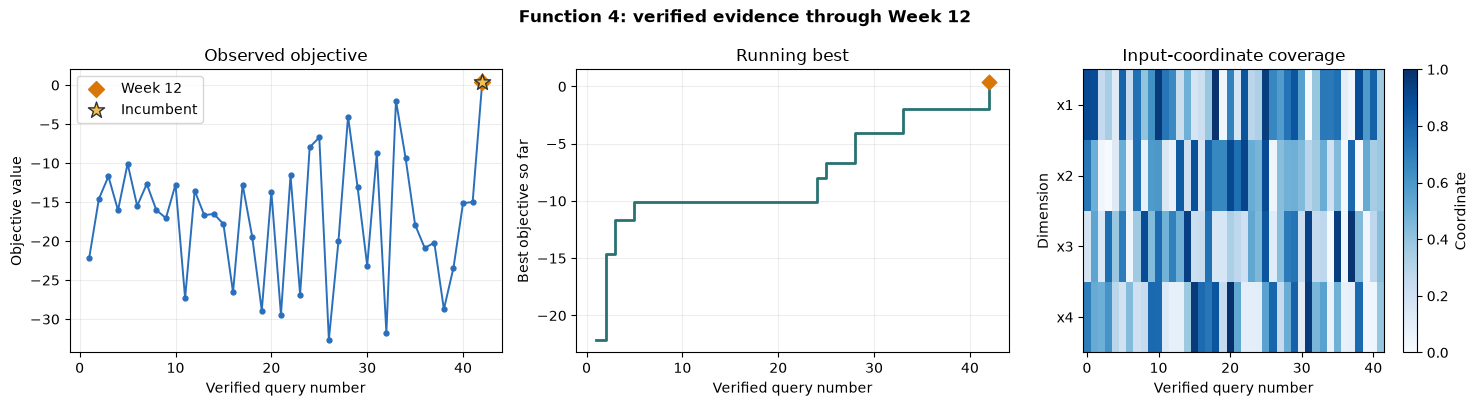

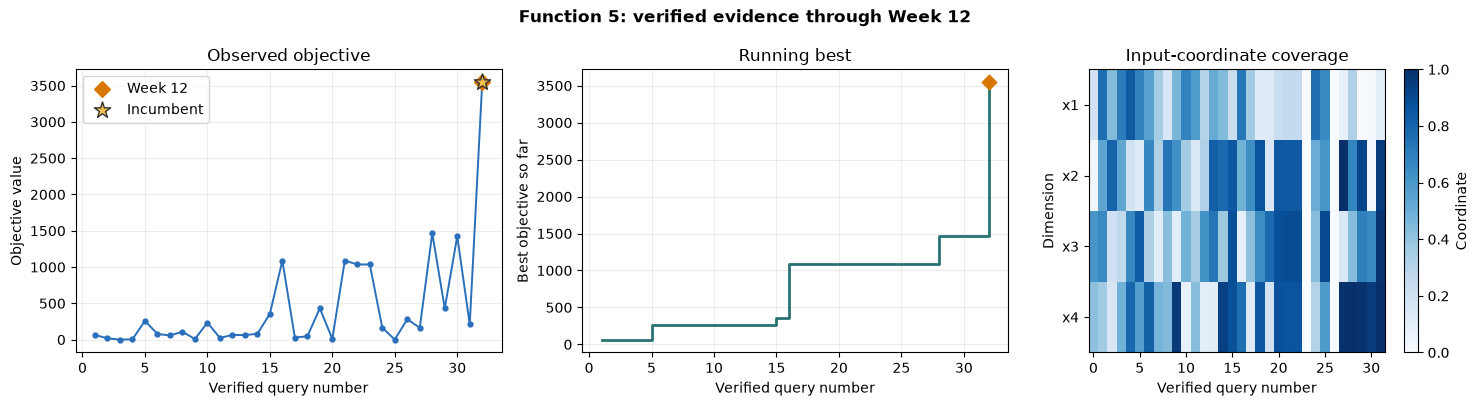

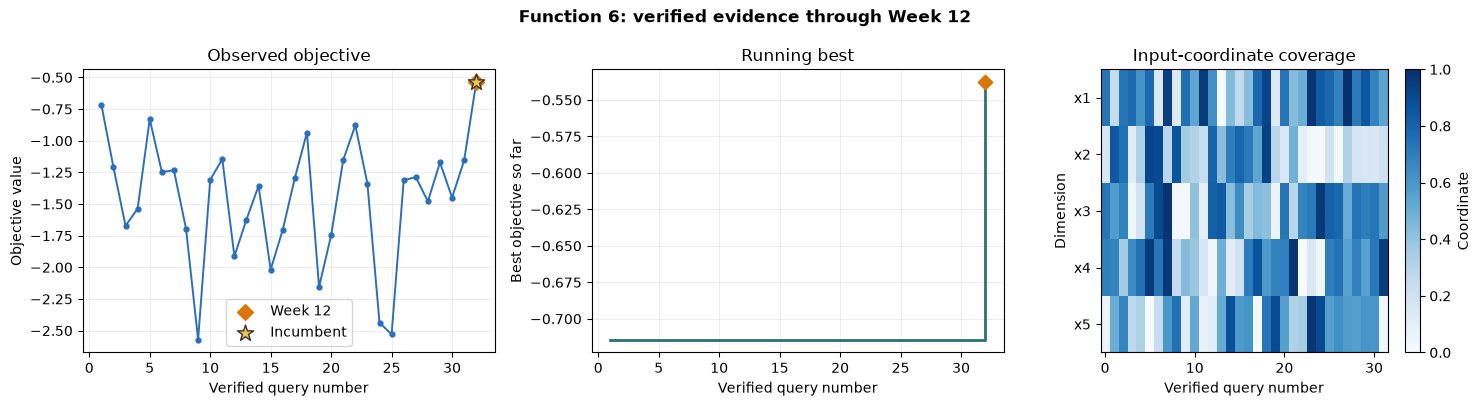

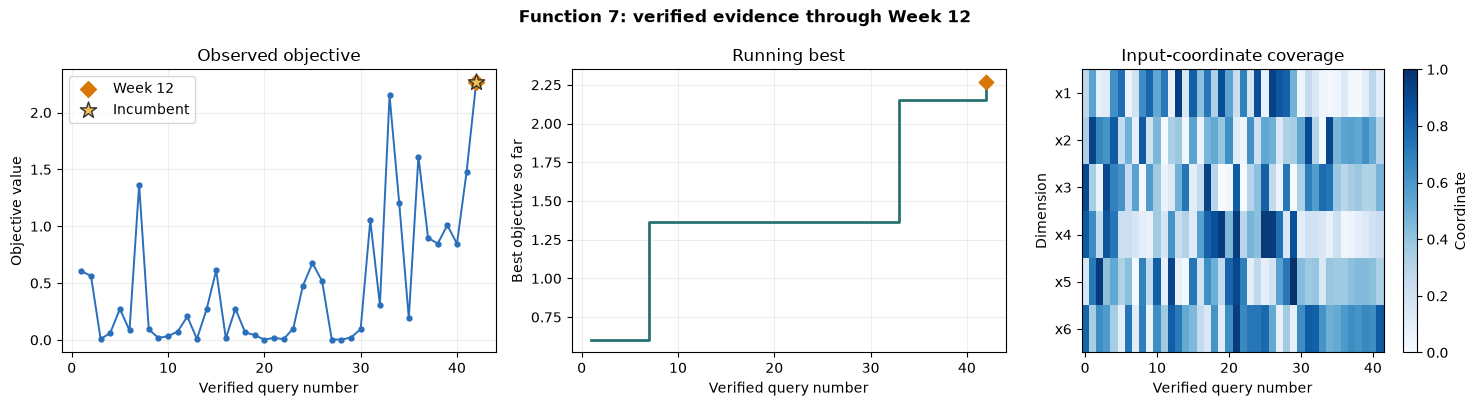

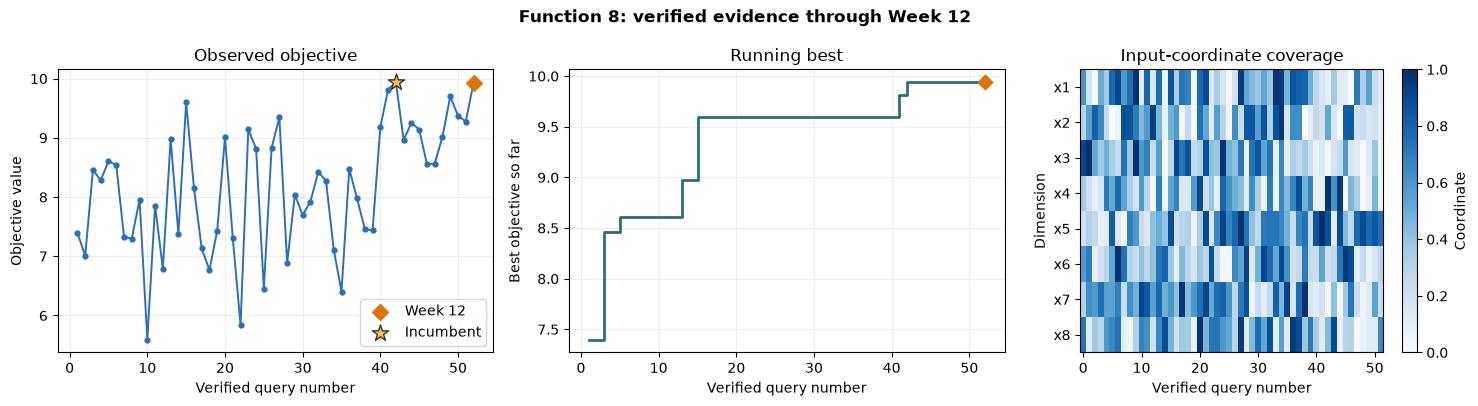

In [6]:
for function,(inputs,outputs) in evidence.items():
    query_number=np.arange(1,len(outputs)+1); incumbent=int(np.argmax(outputs))
    fig,axes=plt.subplots(1,3,figsize=(15,4.1),gridspec_kw={'width_ratios':[1.15,1.15,1]})
    axes[0].plot(query_number,outputs,color='#2a6fbb',marker='o',ms=3.5,lw=1.4)
    axes[0].scatter(query_number[-1],outputs[-1],marker='D',s=65,color='#d97706',label='Week 12',zorder=4)
    axes[0].scatter(query_number[incumbent],outputs[incumbent],marker='*',s=150,color='#f2c14e',edgecolor='#333',label='Incumbent',zorder=5)
    axes[0].set(title='Observed objective',xlabel='Verified query number',ylabel='Objective value'); axes[0].legend()
    axes[1].step(query_number,np.maximum.accumulate(outputs),where='post',color='#287271',lw=2)
    axes[1].scatter(query_number[-1],np.maximum.accumulate(outputs)[-1],marker='D',s=55,color='#d97706',zorder=4)
    axes[1].set(title='Running best',xlabel='Verified query number',ylabel='Best objective so far')
    image=axes[2].imshow(inputs.T,aspect='auto',cmap='Blues',vmin=0,vmax=1)
    axes[2].set(title='Input-coordinate coverage',xlabel='Verified query number',ylabel='Dimension')
    axes[2].set_yticks(range(inputs.shape[1]),[f'x{i+1}' for i in range(inputs.shape[1])]); fig.colorbar(image,ax=axes[2],label='Coordinate')
    for axis in axes[:2]: axis.grid(alpha=.22)
    fig.suptitle(f'Function {function}: verified evidence through Week 12',fontweight='bold'); fig.tight_layout(); plt.show()

### Descriptive coordinate–output associations

Spearman correlations summarise monotonic association only. They can reveal potentially influential coordinates, but they do not establish causality or represent nonlinear interactions completely.

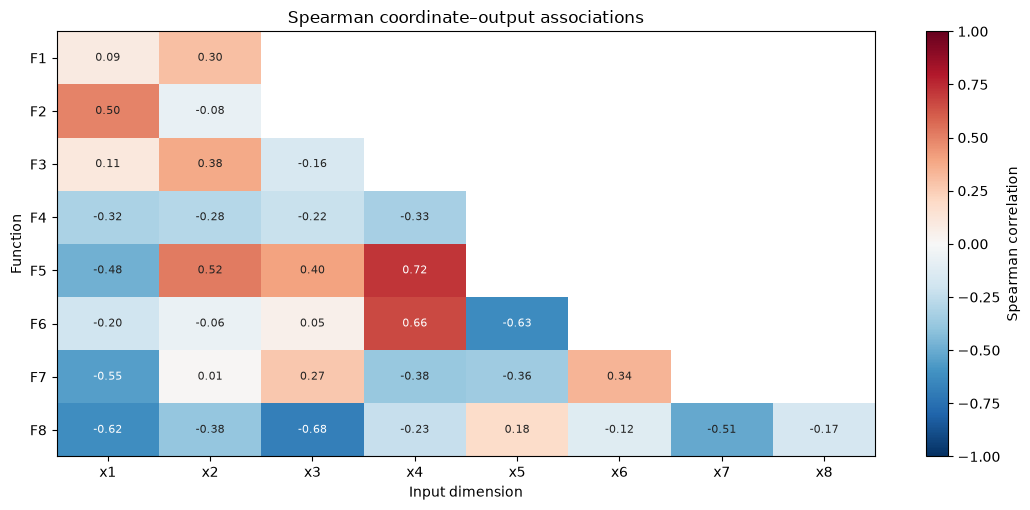

In [7]:
association=np.full((8,8),np.nan)
for function,(inputs,outputs) in evidence.items():
    for dimension in range(inputs.shape[1]): association[function-1,dimension]=pd.Series(inputs[:,dimension]).corr(pd.Series(outputs),method='spearman')
fig,ax=plt.subplots(figsize=(11,5.2)); image=ax.imshow(association,aspect='auto',cmap='RdBu_r',vmin=-1,vmax=1)
ax.set_xticks(range(8),[f'x{i}' for i in range(1,9)]); ax.set_yticks(range(8),[f'F{i}' for i in range(1,9)])
ax.set(title='Spearman coordinate–output associations',xlabel='Input dimension',ylabel='Function')
for i in range(8):
    for j in range(8):
        if np.isfinite(association[i,j]): ax.text(j,i,f'{association[i,j]:.2f}',ha='center',va='center',fontsize=8,color='white' if abs(association[i,j])>.55 else '#222')
fig.colorbar(image,ax=ax,label='Spearman correlation'); fig.tight_layout(); plt.show()

## Results

### UCB, EI and PI comparison

### Pre-outcome acquisition policy

The acquisition choice is made separately for each function from its observed history through Week 12. UCB is retained where sparse signal or dimensionality makes uncertainty-led exploration valuable; EI is used where Week 12 strengthens a promising region while preserving uncertainty; PI is used for F3 because its new incumbent supports controlled exploitation. These choices were recorded before Week 13 outcomes and must not be interpreted as a statistically controlled acquisition comparison.

In [8]:
comparison[['function','method','candidate','candidate_source','predicted_mean','predicted_std','acquisition_score','kappa','xi_fraction_of_output_std']]

,function,method,candidate,candidate_source,predicted_mean,predicted_std,acquisition_score,kappa,xi_fraction_of_output_std
0,1,UCB,"[0.98745,0.502905]",sobol,-0.000049,0.000869,0.002559,3.00,0.010
1,1,EI,"[0.953988,0.532948]",sobol,0.000059,0.000783,0.000339,3.00,0.010
2,1,PI,"[0.756395,0.735903]",local,0.000059,0.000031,0.951826,3.00,0.010
3,2,UCB,"[0.711866,0.0]",local,0.535669,0.100618,0.736904,2.00,0.020
4,2,EI,"[0.686305,0.999999]",local,0.595156,0.055720,0.013610,2.00,0.020
5,2,PI,"[0.695455,0.770806]",local,0.611646,0.026420,0.445645,2.00,0.020
6,3,UCB,"[0.028484,0.967736,0.000487]",sobol,-0.053939,0.080688,0.067093,1.50,0.005
7,3,EI,"[0.279542,0.884932,0.000883]",sobol,-0.035030,0.066037,0.020458,1.50,0.005
8,3,PI,"[0.685419,0.62677,0.366737]",sobol,-0.022132,0.007594,0.507546,1.50,0.005
9,4,UCB,"[0.332326,0.427941,0.445087,0.470215]",local,0.155369,0.341156,1.093548,2.75,0.020


### Acquisition alternatives by function

Acquisition scores are not compared across UCB, EI and PI because they have different mathematical scales. Instead, each panel compares the GP mean and uncertainty at the best candidate identified by each method.

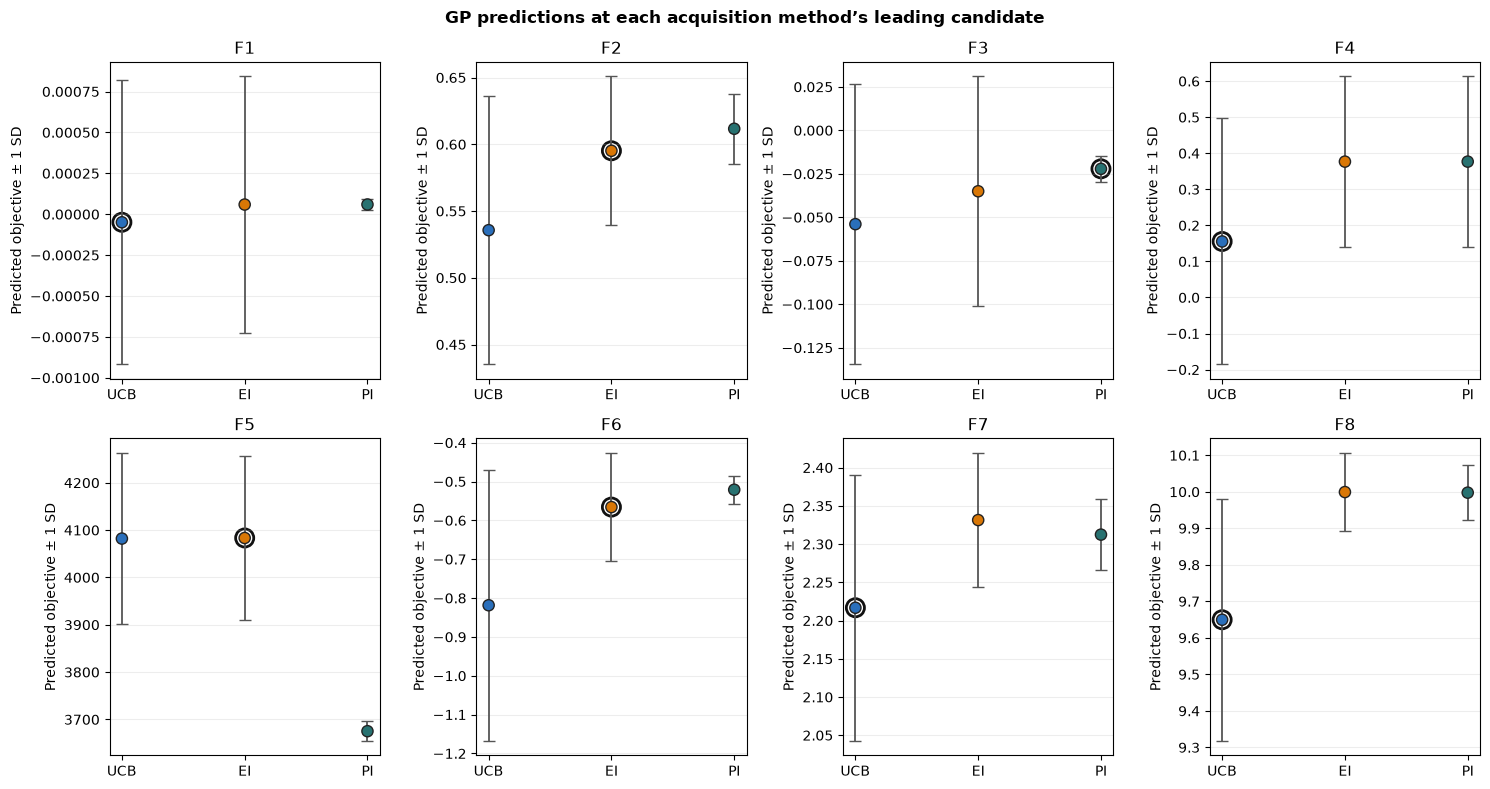

In [9]:
fig,axes=plt.subplots(2,4,figsize=(15,8),sharex=False); colours={'UCB':'#2a6fbb','EI':'#d97706','PI':'#287271'}
for function,axis in zip(range(1,9),axes.ravel()):
    rows=comparison.loc[comparison.function.eq(function)].set_index('method').loc[['UCB','EI','PI']]
    x=np.arange(3); axis.errorbar(x,rows.predicted_mean,yerr=rows.predicted_std,fmt='none',ecolor='#555',capsize=4,lw=1.3)
    axis.scatter(x,rows.predicted_mean,s=65,c=[colours[m] for m in rows.index],edgecolor='#222',zorder=3)
    chosen=strategy.loc[strategy.function.eq(function),'method'].iloc[0]; chosen_x=['UCB','EI','PI'].index(chosen)
    axis.scatter(chosen_x,rows.loc[chosen,'predicted_mean'],s=170,facecolors='none',edgecolors='#111',linewidths=2,label='Selected')
    axis.set_xticks(x,rows.index); axis.set(title=f'F{function}',ylabel='Predicted objective ± 1 SD'); axis.grid(axis='y',alpha=.22)
fig.suptitle('GP predictions at each acquisition method’s leading candidate',fontweight='bold'); fig.tight_layout(); plt.show()

### Selected function-specific strategies

In [10]:
selected=strategy[['function','method','query','kappa','xi_fraction_of_output_std','local_scale','fitted_length_scales','predicted_mean','predicted_std','distance_from_incumbent','reason']]
selected

,function,method,query,kappa,xi_fraction_of_output_std,local_scale,fitted_length_scales,predicted_mean,predicted_std,distance_from_incumbent,reason
0,1,UCB,"[0.98745,0.502905]",3.00,0.010,0.120,"[2.0,0.04547431075476111]",-0.000049,0.000869,0.344526,Sparse near-zero responses still justify uncer...
1,2,EI,"[0.686305,0.999999]",2.00,0.020,0.100,"[0.0460973021331673,2.0]",0.595156,0.055720,0.075229,The strong Week 12 return supports balanced im...
2,3,PI,"[0.685419,0.62677,0.366737]",1.50,0.005,0.035,"[0.5470637199382139,2.0,0.14262670255750265]",-0.022132,0.007594,0.101936,The new best reinforces a stable structure and...
3,4,UCB,"[0.332326,0.427941,0.445087,0.470215]",2.75,0.020,0.140,"[1.5923777675921953,1.5627229462755674,1.51527...",0.155369,0.341156,0.101078,"The large Week 12 improvement is promising, wh..."
4,5,EI,"[0.035438,0.999999,0.999999,0.999999]",1.50,0.010,0.070,"[2.0,0.2577539991563763,0.7201843223717376,2.0]",4083.324047,172.908719,0.080363,The much stronger Week 12 incumbent warrants f...
5,6,EI,"[0.395407,0.091768,0.66226,0.806631,0.0]",1.75,0.010,0.080,"[1.171357473843631,0.836506208205614,1.1252535...",-0.565791,0.139457,0.249899,The Week 12 best supports exploitation with un...
6,7,UCB,"[0.186669,0.174973,0.820528,0.28797,0.334213,0...",2.00,0.010,0.090,"[0.6471386143786568,0.44927735577379907,1.8625...",2.216759,0.174231,0.385336,The new best supports local focus while modera...
7,8,UCB,"[0.032909,0.091943,0.072309,0.221801,0.904654,...",3.00,0.020,0.120,"[1.243294674435118,2.0,1.015505971046498,2.0,2...",9.649621,0.331982,0.984588,A near-best Week 12 result does not remove eig...


### Fitted anisotropic length scales

Shorter fitted length scales indicate faster modelled variation along a coordinate; values at configured bounds should be interpreted cautiously.

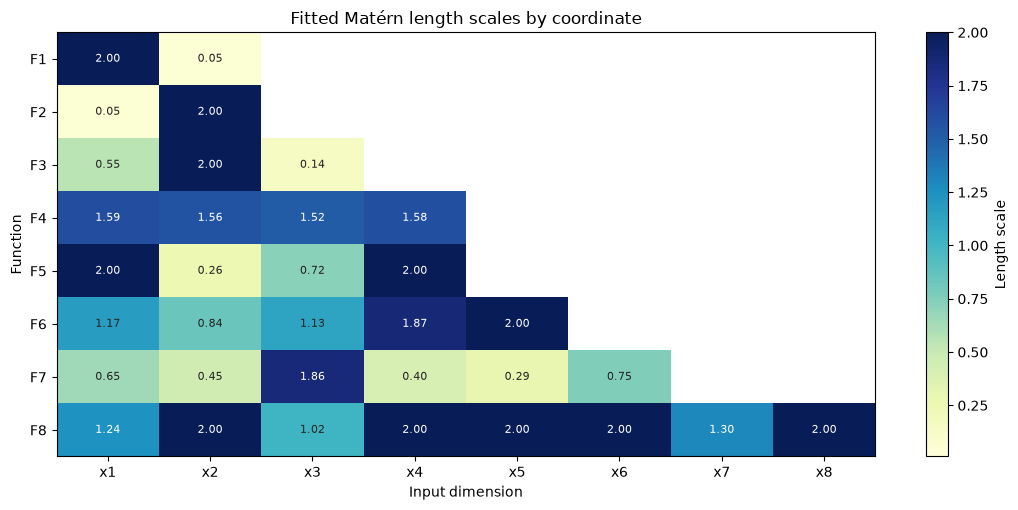

In [11]:
length_scale_matrix=np.full((8,8),np.nan)
for row in strategy.itertuples():
    values=json.loads(row.fitted_length_scales); length_scale_matrix[int(row.function)-1,:len(values)]=values
fig,ax=plt.subplots(figsize=(11,5.2)); image=ax.imshow(length_scale_matrix,aspect='auto',cmap='YlGnBu',vmin=.01,vmax=2)
ax.set_xticks(range(8),[f'x{i}' for i in range(1,9)]); ax.set_yticks(range(8),[f'F{i}' for i in range(1,9)])
ax.set(title='Fitted Matérn length scales by coordinate',xlabel='Input dimension',ylabel='Function')
for i in range(8):
    for j in range(8):
        if np.isfinite(length_scale_matrix[i,j]): ax.text(j,i,f'{length_scale_matrix[i,j]:.2f}',ha='center',va='center',fontsize=8,color='white' if length_scale_matrix[i,j]>1.2 else '#222')
fig.colorbar(image,ax=ax,label='Length scale'); fig.tight_layout(); plt.show()

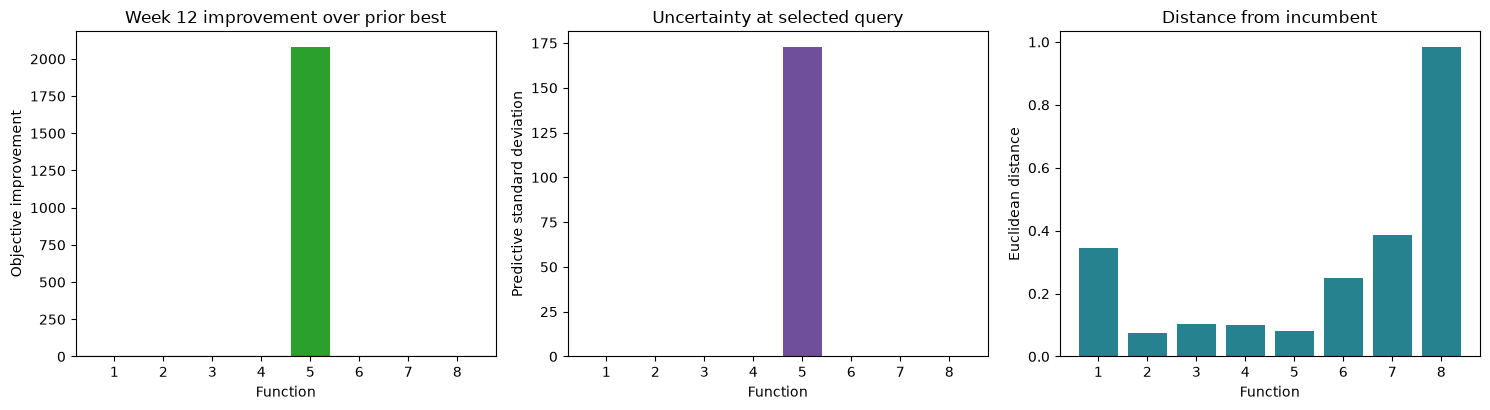

In [12]:
fig,axes=plt.subplots(1,3,figsize=(15,4.2))
axes[0].bar(strategy.function.astype(str),strategy.week_12_improvement,color=np.where(strategy.week_12_improvement>0,'#2ca02c','#9aa0a6'))
axes[0].axhline(0,color='black',lw=.8); axes[0].set(title='Week 12 improvement over prior best',xlabel='Function',ylabel='Objective improvement')
axes[1].bar(strategy.function.astype(str),strategy.predicted_std,color='#6f4e9c'); axes[1].set(title='Uncertainty at selected query',xlabel='Function',ylabel='Predictive standard deviation')
axes[2].bar(strategy.function.astype(str),strategy.distance_from_incumbent,color='#26828e'); axes[2].set(title='Distance from incumbent',xlabel='Function',ylabel='Euclidean distance')
fig.tight_layout(); plt.show()

### Submission strings and integrity checks

In [13]:
lines=(ROOT/'Week_13/01_Queries/week_13_query_points.txt').read_text().strip().splitlines()
for line in lines: print(line)
assert len(lines)==8 and len(strategy)==8 and len(comparison)==24
for row,line in zip(strategy.itertuples(),lines):
    function=int(row.function); query=np.asarray(json.loads(row.query),float)
    assert line==f'Function_{function}:'+'-'.join(f'{value:.6f}' for value in query)
    assert query.shape==(DIMENSIONS[function],)
    assert np.isfinite(query).all() and np.all((query>=0)&(query<=0.999999))
    data=ROOT/f'Week_01/Function_{function:02d}/03_Data'
    observed=np.load(data/'initial_inputs.npy')
    observed=np.vstack([observed]+[np.asarray(q,float)[None,:] for q,_ in pairs_through_week(12,function)])
    assert len(observed)==row.verified_observations
    assert not np.any(np.all(np.isclose(observed,query,rtol=0,atol=5e-7),axis=1))
print('Print week 13 query points')

Function_1:0.987450-0.502905
Function_2:0.686305-0.999999
Function_3:0.685419-0.626770-0.366737
Function_4:0.332326-0.427941-0.445087-0.470215
Function_5:0.035438-0.999999-0.999999-0.999999
Function_6:0.395407-0.091768-0.662260-0.806631-0.000000
Function_7:0.186669-0.174973-0.820528-0.287970-0.334213-0.844074
Function_8:0.032909-0.091943-0.072309-0.221801-0.904654-0.989379-0.024400-0.951853
Print week 13 query points


## Takeaways

- Week 12 establishes new verified incumbents for F3, F4, F5, F6 and F7; F2 is close to its existing best and F8 is also near its best.
- UCB remains appropriate for F1 and F8 because their useful signal is sparse relative to the search space.
- EI or PI provides stronger exploitation for functions whose Week 12 results reinforce promising regions.
- The proposed coordinates are not evaluations. They may enter the immutable ledger only after eight aligned platform outputs are returned.